**dataset.py**

In [20]:
import os
import re
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

GESTURE_PATTERN = re.compile(r"^\d+_(.+)$")

class LeapGestRecogDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []  # list of (filepath, label_idx)
        self.classes = []

        self._build_index() # collect the gesture names

    def _build_index(self):
        labels = set()

        for subject_dir in sorted(self.root_dir.iterdir()):
            if not subject_dir.is_dir():
                continue
            for gesture_dir in sorted(subject_dir.iterdir()):
                match = GESTURE_PATTERN.match(gesture_dir.name)
                if not match:
                    continue
                label = match.group(1)
                labels.add(label)

        self.classes = sorted(labels)
        class_to_idx = {c: i for i, c in enumerate(self.classes)} # turn the classes names to numbers for the cnn

        for subject_dir in sorted(self.root_dir.iterdir()):
            if not subject_dir.is_dir():
                continue
            for gesture_dir in sorted(subject_dir.iterdir()):
                match = GESTURE_PATTERN.match(gesture_dir.name)
                if not match:
                    continue
                label = match.group(1)
                label_idx = class_to_idx[label]
                for img_path in gesture_dir.glob("*.png"):
                    self.samples.append((img_path, label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("L")  # grayscale
        if self.transform:
            image = self.transform(image)
        return image, label


def get_dataloaders(root_dir, batch_size=32, val_subjects=("08", "09"), img_size=64):
    train_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomRotation(20),
        transforms.RandomAffine(degrees=0, translate=(0.15, 0.15), scale=(0.85, 1.15)),
        transforms.ToTensor(),
    ])

    val_transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
    ])

    train_full = LeapGestRecogDataset(root_dir, transform=train_transform)
    val_full = LeapGestRecogDataset(root_dir, transform=val_transform)

    train_indices = []
    val_indices = []

    for i, (img_path, _) in enumerate(train_full.samples):
        subject = img_path.parent.parent.name
        if subject in val_subjects:
            val_indices.append(i)
        else:
            train_indices.append(i)

    train_ds = torch.utils.data.Subset(train_full, train_indices)
    val_ds = torch.utils.data.Subset(val_full, val_indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, train_full.classes


**model.py**

In [21]:
import torch.nn as nn
import torch.nn.functional as F


class GestureCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 1 channel in (grayscale)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)

        # after 3 pools on 64x64 -> 8x8 feature map
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 64x64 -> 32x32
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 32x32 -> 16x16
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 16x16 -> 8x8

        x = x.view(x.size(0), -1)  # flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

**train.py**

Using device: cuda
Classes: ['c', 'down', 'fist', 'fist_moved', 'index', 'l', 'ok', 'palm', 'palm_moved', 'thumb']


Epoch 1/15: 100%|██████████| 500/500 [00:45<00:00, 10.94it/s, acc=0.62, loss=1.05] 


Epoch 1/15 | train_loss=1.0473 train_acc=0.6200 | val_loss=0.3922 val_acc=0.8520


Epoch 2/15: 100%|██████████| 500/500 [00:44<00:00, 11.16it/s, acc=0.901, loss=0.302]


Epoch 2/15 | train_loss=0.3024 train_acc=0.9006 | val_loss=0.3190 val_acc=0.9028


...

Epoch 13/15 | train_loss=0.0605 train_acc=0.9812 | val_loss=0.3148 val_acc=0.9205


Epoch 14/15: 100%|██████████| 500/500 [00:45<00:00, 10.98it/s, acc=0.989, loss=0.0333]


Epoch 14/15 | train_loss=0.0333 train_acc=0.9892 | val_loss=0.1401 val_acc=0.9650


Epoch 15/15: 100%|██████████| 500/500 [00:45<00:00, 10.93it/s, acc=0.988, loss=0.037] 


Epoch 15/15 | train_loss=0.0370 train_acc=0.9883 | val_loss=0.1052 val_acc=0.9605


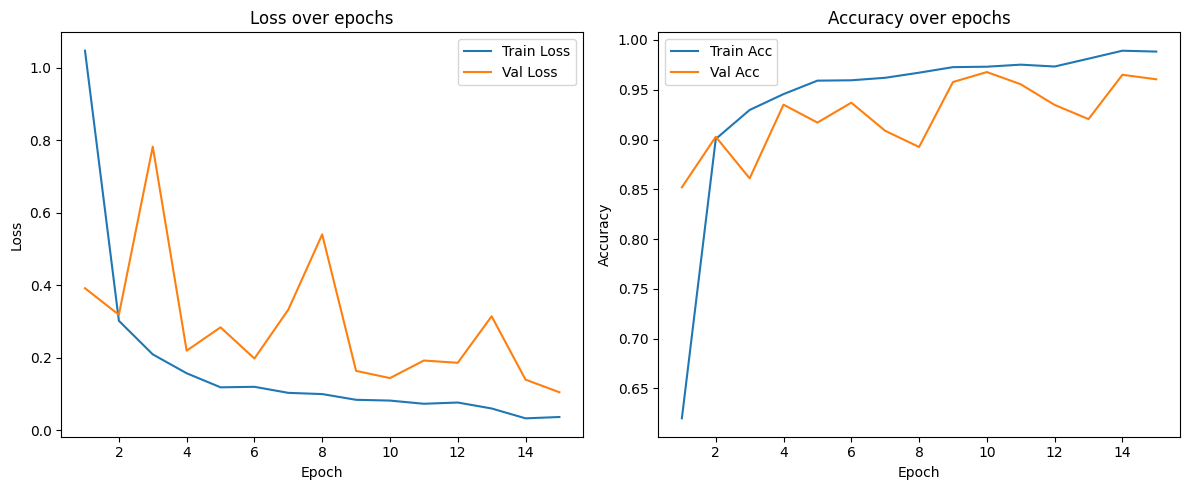

Saved training curves to training_curves.png


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt


DATA_ROOT = "/kaggle/input/datasets/gti-upm/leapgestrecog/leapGestRecog"
BATCH_SIZE = 32
EPOCHS = 15
LR = 0.001
IMG_SIZE = 64
VAL_SUBJECTS = ("08", "09")

MODEL_OUTPUT_PATH = "model.pth"
PLOT_OUTPUT_PATH = "training_curves.png"


def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    train_loader, val_loader, classes = get_dataloaders(
        DATA_ROOT, batch_size=BATCH_SIZE, val_subjects=VAL_SUBJECTS, img_size=IMG_SIZE
    )
    print(f"Classes: {classes}")

    model = GestureCNN(num_classes=len(classes)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=True)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            batch_acc = correct / total
            loop.set_postfix(loss=running_loss / total, acc=batch_acc)

        train_loss = running_loss / total
        train_acc = correct / total

        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:          # <-- add this block
            best_val_acc = val_acc
            torch.save({
                "model_state_dict": model.state_dict(),
                "classes": classes,
            }, MODEL_OUTPUT_PATH)

        print(f"Epoch {epoch+1}/{EPOCHS} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    plot_history(history)


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title("Loss over epochs")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title("Accuracy over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(PLOT_OUTPUT_PATH)
    plt.show()
    print(f"Saved training curves to {PLOT_OUTPUT_PATH}")


if __name__ == "__main__":
    train()